In [23]:

import torch 
import numpy as np 
import librosa 
import scipy.io as sio
from scipy import signal as sig
import scipy
import torch
import torchaudio.functional as F
import torchaudio.transforms as T


%matplotlib inline
import matplotlib.pyplot as plt
import yaml

In [2]:
path = '../config/coch_word_rec/word_rec_1e-4lr.yaml'
config = yaml.load(open(path, 'r'), Loader=yaml.FullLoader)

In [8]:
def ERB_space(lowFreq=100, highFreq=44100/4, N=100):
    '''
    Python port from Malcom Slaney's Audio Toolbox 
    Port by Ian Griffith. August 24, 2021. 

    This function computes an array of N frequencies uniformly spaced between
    highFreq and lowFreq on an ERB scale.  N is set to 100 if not specified.

    See also linspace, logspace, MakeERBCoeffs, MakeERBFilters.

    For a definition of ERB, see Moore, B. C. J., and Glasberg, B. R. (1983).
    "Suggested formulae for calculating auditory-filter bandwidths and
    excitation patterns," J. Acoust. Soc. Am. 74, 750-753.'''


    # Change the following three parameters if you wish to use a different
    # ERB scale.  Must change in MakeERBCoeffs too.
    EarQ = 9.26449            #  Glasberg and Moore Parameters
    minBW = 24.7
    order = 1
#     print(highFreq)
    # All of the followFreqing expressions are derived in Apple TR #35, "An
    # Efficient Implementation of the Patterson-Holdsworth Cochlear
    # Filter Bank."  See pages 33-34.
    freq_ixs = np.arange(N).reshape(1,-1) + 1 # +1 to match matlab (1:N) construction
    
    cfArray = -(EarQ*minBW) + np.exp(freq_ixs.T * (-np.log(highFreq + EarQ*minBW) + 
            np.log(lowFreq + EarQ*minBW))/ N) * (highFreq + EarQ*minBW)
    return cfArray

def make_ERB_filters(fs,numChannels,lowFreq):
    ''' 
     Python port from Malcom Slaney's Audio Toolbox 
     Port by Ian Griffith. August 24, 2021. 
     
     This function computes the filter coefficients for a bank of 
     Gammatone filters.  These filters were defined by Patterson and 
     Holdworth for simulating the cochlea.  

     The result is returned as an array of filter coefficients.  Each row 
     of the filter arrays contains the coefficients for four second order 
     filters.  The transfer function for these four filters share the same
     denominator (poles) but have different numerators (zeros).  All of these
     coefficients are assembled into one vector that the ERBFilterBank 
     can take apart to implement the filter.

     The filter bank contains "numChannels" channels that extend from
     half the sampling rate (fs) to "lowFreq".  Alternatively, if the numChannels
     input argument is a vector, then the values of this vector are taken to
     be the center frequency of each desired filter.  (The lowFreq argument is
     ignored in this case.)
    '''
    
    t = 1/fs
           
    # cf is array of center frequencies 
#     print(lowFreq)
    
    if isinstance(numChannels, np.ndarray):
        cf = numChannels[1:]
        if cf.shape[1] > cf.shape[0]:
            cf = cf.T
    else:
         cf = ERB_space(lowFreq, fs/2, numChannels) 
            
            
    # Change the followFreqing three parameters if you wish to use a different
    # ERB scale.  Must change in ERBSpace too.
    earQ = 9.26449        #  Glasberg and Moore Parameters
    minBW = 24.7
    order = 1
    
    erb = (((cf/earQ)**order) + minBW ** order) ** (1/order)
    b=1.019*2*np.pi*erb
    
    a0 = t
    a2 = 0
    b0 = 1
    b1 = -2*np.cos(2*cf*np.pi*t)/np.exp(b*t)
    b2 = np.exp(-2*b*t)
    
    
    a11 = -(2*t*np.cos(2*cf*np.pi*t)/np.exp(b*t) + 2*np.sqrt(3+2**1.5)*t*np.sin(2*cf*np.pi*t)/
            np.exp(b*t))/2
    a12 = -(2*t*np.cos(2*cf*np.pi*t)/np.exp(b*t) - 2*np.sqrt(3+2**1.5)*t*np.sin(2*cf*np.pi*t)/ 
            np.exp(b*t))/2
    a13 = -(2*t*np.cos(2*cf*np.pi*t)/np.exp(b*t) + 2*np.sqrt(3-2**1.5)*t*np.sin(2*cf*np.pi*t)/ 
            np.exp(b*t))/2
    a14 = -(2*t*np.cos(2*cf*np.pi*t)/np.exp(b*t) - 2*np.sqrt(3-2**1.5)*t*np.sin(2*cf*np.pi*t)/ 
            np.exp(b*t))/2

    gain = abs((-2*np.exp(4*1j*cf*np.pi*t)*t + 
                     2*np.exp(-(b*t) + 2*1j*cf*np.pi*t)*t* 
                             (np.cos(2*cf*np.pi*t) - np.sqrt(3 - 2**(3/2))* 
                              np.sin(2*cf*np.pi*t))) * 
               (-2*np.exp(4*1j*cf*np.pi*t)*t + 
                 2*np.exp(-(b*t) + 2*1j*cf*np.pi*t)*t* 
                  (np.cos(2*cf*np.pi*t) + np.sqrt(3 - 2**(3/2)) * 
                   np.sin(2*cf*np.pi*t)))* 
               (-2*np.exp(4*1j*cf*np.pi*t)*t + 
                 2*np.exp(-(b*t) + 2*1j*cf*np.pi*t)*t* 
                  (np.cos(2*cf*np.pi*t) - 
                   np.sqrt(3 + 2**(3/2))*np.sin(2*cf*np.pi*t))) * 
               (-2*np.exp(4*1j*cf*np.pi*t)*t + 2*np.exp(-(b*t) + 2*1j*cf*np.pi*t)*t* 
               (np.cos(2*cf*np.pi*t) + np.sqrt(3 + 2**(3/2))*np.sin(2*cf*np.pi*t))) / 
              (-2 / np.exp(2*b*t) - 2*np.exp(4*1j*cf*np.pi*t) +  
               2*(1 + np.exp(4*1j*cf*np.pi*t))/np.exp(b*t))**4)
    allfilts = np.ones((max(cf.shape),1)) 
    fcoefs = np.hstack([a0*allfilts, a11, a12, a13, a14, a2*allfilts, b0*allfilts, b1, b2, gain])
    return fcoefs , cf

# @torch.jit.script
def ERB_filter_bank(x: torch.Tensor, fcoefs: torch.Tensor) -> torch.Tensor:
    r"""Processes a wavform with an ERB filter bank using an IIR filter.
    
    Args:
        x (torch.Tensor): with shape `(Batch, Channels, Time)`.
        fcoefs (torch.Tensor): tensor of ERB filterbank coefficients
            with shape '(n_channels, 10)'.

    Returns:
        (torch.Tensor):
            torch.Tensor
                y, with shape `(Batch, Channels, Time)`.

    """
    

    if fcoefs.shape[1] != 10:
        raise ValueError('fcoefs parameter passed to ERBFilterBank is the wrong size.')
    
    a1 = fcoefs[:, [0,1,5]]
    a2 = fcoefs[:, [0,2,5]]
    a3 = fcoefs[:, [0,3,5]]
    a4 = fcoefs[:, [0,4,5]]

    b_coefs = fcoefs[:,[6,7,8]]
    
    gain = fcoefs[:,9].unsqueeze(1)

    # Apply cascade of low-pass filters 
    # for ref on clamp and batching args:
    # https://pytorch.org/audio/0.10.0/functional.html#lfilter 
    # Current settings match output from matlab and numpy implementations
    
    # Note: following Slaney implementation where b = A and a = B 
    # in lfilter input args 
    y = F.lfilter(x, b_coefs, 
                 torch.div(a1, gain), clamp=False, batching=False)

    y = F.lfilter(y, b_coefs, a2, clamp=False, batching=True)

    y = F.lfilter(y, b_coefs, a3, clamp=False, batching=True)

    y = F.lfilter(y, b_coefs, a4, clamp=False, batching=True)

    return y # remove extra dim added by lfilter

def backend_hann2d(x, ramp_dur_ms, samplerate=48000):
    stim_dur_smp = x.shape[1] # N taps of x
    ramp_dur_smp =  np.floor(ramp_dur_ms * samplerate / 1000).astype('int')
    assert stim_dur_smp > (2*ramp_dur_smp), 'Ramps cannot be longer than the stimulus duration'
    
    # calc window
    # https://stackoverflow.com/questions/56485663/hanning-window-values-doesnt-match-in-python-and-matlab
    win = sig.hann((2 * ramp_dur_smp) + 2)[1:-1]
    
    # Middle part (steady state)
    steady_win = x[:,:stim_dur_smp-ramp_dur_smp]
    
    # Final part of windowed stimulus
    end_win = win[ramp_dur_smp : ramp_dur_smp*2] * x[:, stim_dur_smp-ramp_dur_smp:stim_dur_smp]

    return np.hstack([steady_win, end_win])


In [192]:
class ComputeSubbands(torch.nn.Module):
    """
    Convolves input with impulse response of filters in cochlear filter
    bank.
    """
    def __init__(self, coch_filters, use_pad):
        super(ComputeSubbands, self).__init__()
        self.use_pad = use_pad
        self.n_taps = coch_filters.shape[1]
        self.pad_factor = self.n_taps - 1 # need odd number for total len
        print(f"{self.pad_factor=}")
#         coch_filters = torch.nn.functional.pad(coch_filters, ((self.pad_factor,0)), mode='constant', value=0)
        self.n_channels = coch_filters.shape[0]
        coch_filters = coch_filters.unsqueeze(1)
        self.register_buffer("coch_filters", coch_filters)

    def forward(self, x):
        x_shape = x.shape
        if len(x_shape)>2:
            x = x.view(x_shape[0]*x_shape[-2], 1, -1)
        else: # Handle the case where there is no batch dimension
            x = x.view(x_shape[0], 1, -1)
        print(x.shape)
#         if self.use_pad:
        x = torch.nn.functional.pad(x, ((self.pad_factor,0)), mode='constant', value=0)

        x = torch.nn.functional.conv1d(x, self.coch_filters, padding='valid')
        print(x.shape)
        x = x.view(x_shape[0], 1, self.n_channels, -1)
        return x

In [193]:
erb_coefs, cf = make_ERB_filters(20000,
                                  40,
                                  40)
erb_coefs = torch.from_numpy(erb_coefs).float()

use_pad=True
# if on_gpu - we'll pre-fab an impulse response for a convolutional FIR filter:
window_size = 10
ir = torch.hstack([torch.ones(1,1), torch.zeros(1,20000-1)])
kernel = ERB_filter_bank(ir, erb_coefs)
# window kernel
kernel =  backend_hann2d(kernel.numpy().squeeze(), window_size, 20000)
kernel = torch.from_numpy(kernel).float()
kernel = torch.fliplr(kernel) # needed for conv layer to perform conv not auto. cor. 
compute_rep = ComputeSubbands(kernel, use_pad)

self.pad_factor=19999


In [69]:
import sys 
sys.path.append('/om4/group/mcdermott/user/imgriff/projects/End-to-end-ASR-Pytorch')

from corpus.jsinV3DataLoader_precombined import jsinV3_precombined
# import src.custom_modules as cm 
import src.audio_transforms as at
sys.path.append('/om/user/imgriff/python-packages/')
import chcochleagram
import chcochleagram.compression as compression
import chcochleagram.downsampling as downsampling
# from src.coch_word_rec_lightning import CochWordRecModule



In [70]:
audio_config = config['data']['audio']
corpora_config = config['data']['corpus']
loader_config = config['data']['loader']

audio_transforms = at.AudioCompose([
    at.AudioToTensor(),
#     at.CombineWithRandomDBSNR(low_snr=-10, high_snr=10),
    at.RMSNormalizeForegroundAndBackground(rms_level=0.1),
    at.UnsqueezeAudio(dim=0),
])

In [71]:
dataset = jsinV3_precombined(**config['data']['corpus'], train=True, transform=audio_transforms)


KeyboardInterrupt



In [84]:
config['n_jobs'] = 1
config['data']['audio']['rep_kwargs']['rep_on_gpu'] = True
config['data']['audio']['rep_kwargs']['use_pad'] = True

config['data']['loader']['batch_size'] = 1


In [96]:
config['data']['audio']

{'rep_type': 'cochlea_filt',
 'rep_kwargs': {'sr': 20000,
  'env_sr': 8000,
  'n_channels': 40,
  'low_lim': 40,
  'use_pad': True,
  'rep_on_gpu': True,
  'env_extraction_type': 'Half-wave Rectification',
  'downsampling_type': 'TorchTransformsResample',
  'downsampling_kwargs': {'lowpass_filter_width': 64,
   'rolloff': 0.9475937167399596,
   'resampling_method': 'kaiser_window',
   'beta': 14.769656459379492}},
 'compression_type': 'coch_p3',
 'compression_kwargs': {'scale': 1,
  'offset': 1e-07,
  'clip_value': 5,
  'power': 0.3}}

In [125]:
compression_op = compression.ClippedGradPowerCompression(**audio_config['compression_kwargs'])
downsample = T.Resample
downsample_op = downsample(20000, 8000,**audio_config['rep_kwargs']['downsampling_kwargs'], dtype=torch.float32)

In [196]:
audio_rep = torch.nn.Sequential(compute_rep, torch.nn.ReLU(), downsample_op, compression_op)

In [195]:
class compute_cpu(torch.nn.Module):
    def __init__(self):
        super(compute_cpu, self).__init__()
        self.compute = lambda x: ERB_filter_bank(x, erb_coefs)
    def forward(self, x):
        return self.compute(x)
    
compute_cpu_rep = compute_cpu()
cpu_rep = torch.nn.Sequential(compute_cpu_rep, torch.nn.ReLU(), downsample_op, compression_op).cpu()

In [197]:
audio_rep = audio_rep.cuda()

In [238]:
data, lable = zip(*[dataset[ix] for ix in [0,2]])

In [241]:
data = torch.cat(data, axis=0)

In [242]:
data.shape

torch.Size([2, 40000])

In [244]:
features = audio_rep(data.cuda())
print(features.shape)

torch.Size([2, 1, 40000])
torch.Size([2, 40, 40000])
torch.Size([2, 1, 40, 16000])


In [167]:
cpu_feats = cpu_rep(data.cpu())
print(cpu_feats)

tensor([[[0.1626, 0.2073, 0.1751,  ..., 0.0336, 0.0321, 0.0412],
         [0.1180, 0.1801, 0.2555,  ..., 0.0261, 0.0272, 0.0307],
         [0.0855, 0.1858, 0.2377,  ..., 0.0355, 0.0353, 0.0359],
         ...,
         [0.0081, 0.0096, 0.0119,  ..., 0.0832, 0.0848, 0.0903],
         [0.0080, 0.0092, 0.0111,  ..., 0.0079, 0.0085, 0.0079],
         [0.0080, 0.0088, 0.0104,  ..., 0.0079, 0.0079, 0.0079]]])


In [245]:
gpu_features = features.cpu().squeeze()

In [246]:
print(gpu_features.shape)

torch.Size([2, 40, 16000])


Text(0.5, 1.0, 'on GPU')

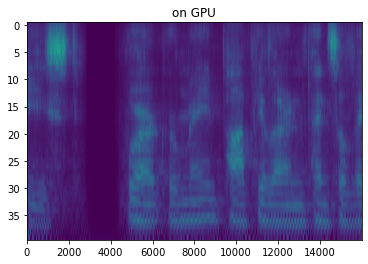

In [248]:
plt.imshow(gpu_features[1], aspect='auto')
plt.title('on GPU')

In [168]:
cpu_feats = cpu_feats.squeeze()

In [169]:
cpu_feats.shape

torch.Size([40, 16000])

Text(0.5, 1.0, 'on CPU')

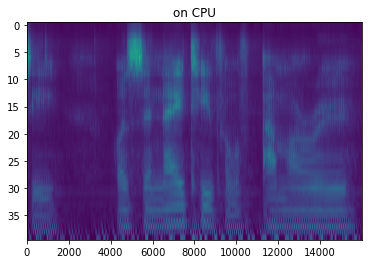

In [170]:
plt.imshow(cpu_feats, aspect='auto')
plt.title('on CPU')

In [225]:
torch.equal(gpu_features, cpu_feats)

False

Text(0.5, 1.0, 'Difference: abs(GPU - CPU)')

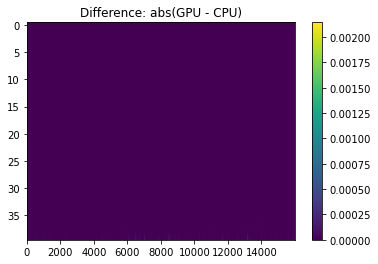

In [227]:
diff = abs(gpu_features - cpu_feats)
plt.imshow(diff, vmin=0, vmax=diff.max(), aspect='auto')
plt.colorbar()
plt.title('Difference: abs(GPU - CPU)')